# Editable Gothic Cloud Frequency Plot (Lat/Lon + DEM)

Edit the parameters in the next cell, then run all cells to regenerate the PNG.

In [ ]:
from pathlib import Path

# Inputs
mask_path = Path('/glade/derecho/scratch/cdalden/gothic/goes16/cloud_mask_tempbin_10c/goes16_cloud_binary_tempbin10c_gothic_202207_monthly.nc')
ortho_map_path = Path('/glade/u/home/cdalden/.ortho_cache/ortho_map_ce81dc15_00bab0b9.nc')

# Output
out_png = Path('/glade/u/home/cdalden/goes_work/analysis/gothic_cloud_frequency_202207_4panel_diurnal.png')

# Time windows (UTC, since data is in UTC)
# 9-10am MDT = 15-16 UTC, 11-12pm MDT = 17-18 UTC, 2-3pm MDT = 20-21 UTC, 4-5pm MDT = 22-23 UTC
time_windows = [
    (15, 16, '9-10am MDT'),
    (17, 18, '11am-12pm MDT'),
    (20, 21, '2-3pm MDT'),
    (22, 23, '4-5pm MDT'),
]

# Plot styling (edit these)
figsize = (12, 10)
dpi = 140
cloud_cmap = 'gist_stern'
cloud_vmin = 0
cloud_vmax = 80
cloud_alpha = 0.8
hillshade_cmap = 'Greys'
hillshade_alpha = 0.3

# Hillshade settings
hs_azdeg = 315
hs_altdeg = 45
hs_vert_exag = 1.2

title = 'Gothic Cloud Frequency by Time Window (July 2022)\nLat/Lon with DEM Hillshade'


In [28]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import pandas as pd

mask_ds = xr.open_dataset(mask_path)
map_ds = xr.open_dataset(ortho_map_path)

# Extract time and compute hourly windows
time_coord = pd.to_datetime(mask_ds['t'].values)
hours = time_coord.hour

# Compute cloud fraction for each time window
cf_windows = {}
for start_hour, end_hour, label in time_windows:
    # Select data for this hour window (inclusive of start, exclusive of end)
    mask_in_window = (hours >= start_hour) & (hours < end_hour)
    cf_window = mask_ds['cloud_binary'].isel(t=mask_in_window).mean(dim='t') * 100.0
    cf_windows[label] = cf_window

# Remap to lat/lon using ortho lookup arrays
dem_x = map_ds['dem_px_angle_x']
dem_y = map_ds['dem_px_angle_y']

cf_ll_windows = {}
for label, cf in cf_windows.items():
    cf_ll = cf.interp(x=dem_x, y=dem_y, method='nearest')
    cf_ll_windows[label] = cf_ll

# Elevation + hillshade
elev = map_ds['elevation'].values
lon = map_ds['longitude'].values
lat = map_ds['latitude'].values

ls = LightSource(azdeg=hs_azdeg, altdeg=hs_altdeg)
dx = float(np.mean(np.abs(np.diff(lon))))
dy = float(np.mean(np.abs(np.diff(lat))))
hillshade = ls.hillshade(elev, vert_exag=hs_vert_exag, dx=dx, dy=dy)


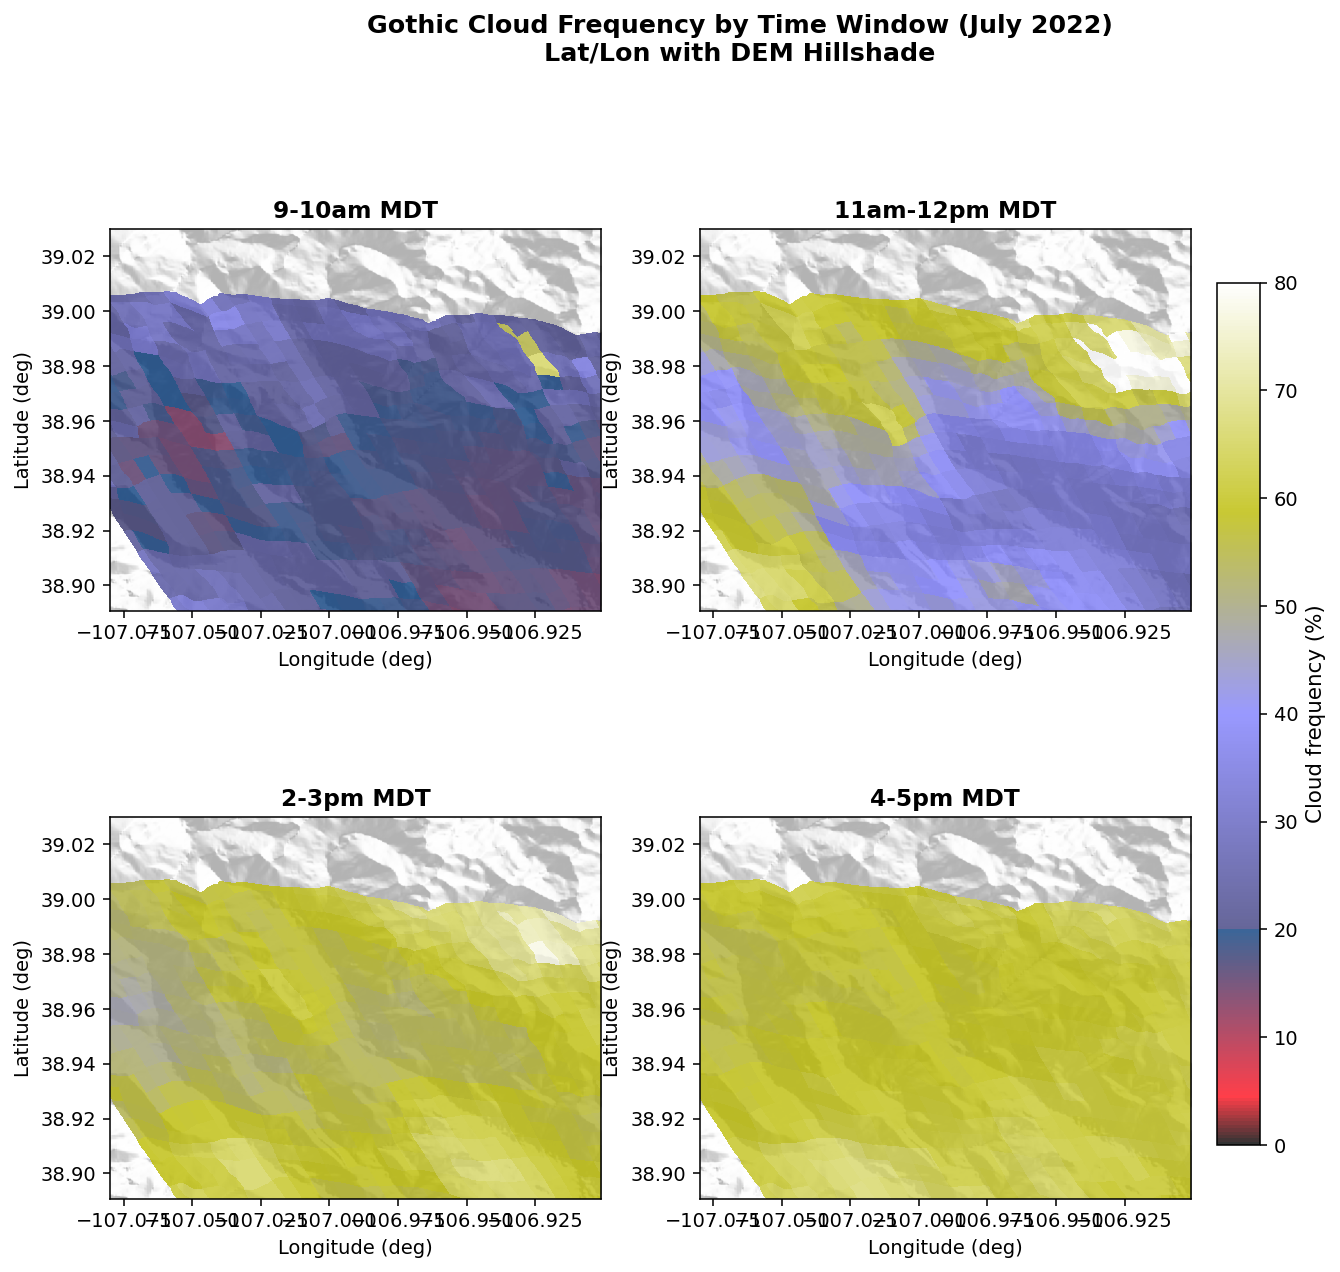

In [30]:
fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=dpi)
axes = axes.flatten()

mesh_list = []
for idx, (start_hour, end_hour, label) in enumerate(time_windows):
    ax = axes[idx]
    
    # Hillshade background
    ax.imshow(
        hillshade,
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        origin='lower',
        cmap=hillshade_cmap,
        alpha=hillshade_alpha,
    )
    
    # Cloud fraction overlay
    cf_ll = cf_ll_windows[label]
    mesh = ax.pcolormesh(
        lon,
        lat,
        cf_ll.values,
        shading='auto',
        cmap=cloud_cmap,
        vmin=0,
        vmax=80,
        alpha=cloud_alpha,
    )
    mesh_list.append(mesh)
    
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude (deg)', fontsize=10)
    ax.set_ylabel('Latitude (deg)', fontsize=10)
    ax.set_xlim(lon.min(), lon.max())
    ax.set_ylim(lat.min(), lat.max())

# Single colorbar for all panels
cbar = fig.colorbar(mesh_list[0], ax=axes, pad=0.02, shrink=0.8)
cbar.set_label('Cloud frequency (%)', fontsize=11)

fig.suptitle(title, fontsize=13, fontweight='bold', y=0.995)
# fig.tight_layout()
# fig.savefig(out_png, dpi=dpi, bbox_inches='tight')
plt.show()


In [16]:
print(f'Wrote: {out_png}\n')
for label, cf_ll in cf_ll_windows.items():
    cf_values = cf_ll.values
    print(f'{label}:')
    print(f'  Mean cloud frequency: {float(np.nanmean(cf_values)):.2f}%')
    print(f'  Min/Max: {float(np.nanmin(cf_values)):.2f}% / {float(np.nanmax(cf_values)):.2f}%')


Wrote: /glade/u/home/cdalden/goes_work/analysis/gothic_cloud_frequency_202207_4panel_diurnal.png

9-10am MDT:
  Mean cloud frequency: 20.41%
  Min/Max: 13.17% / 66.40%
11am-12pm MDT:
  Mean cloud frequency: 46.95%
  Min/Max: 25.00% / 95.16%
2-3pm MDT:
  Mean cloud frequency: 58.07%
  Min/Max: 46.77% / 77.69%
4-5pm MDT:
  Mean cloud frequency: 60.19%
  Min/Max: 54.84% / 67.74%
